# Week 5: HealthConnect Experience Lab
## Data Preparation, Feature Engineering & Baseline Model Development

**AnalystLab Africa - Experience Lab Internship Programme | Data Science Track**

**Project:** HealthConnect Clinic Experience Lab - Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

Week 5 moves from the Week 4 planning stage into practical work: preparing the data, engineering features, defining a train/test strategy, and training a baseline classification model. Per the brief, the goal here is a **reliable baseline**, not the best-performing model - that refinement is reserved for Week 6.


## Part 1: Review of Week 4 Foundation

**Problem defined in Week 4:** Predict, before an appointment happens, whether a patient will fail to attend (`No-Show`), so HealthConnect Clinic can intervene early.

**Week 4 proposed approach:** Binary classification (`did_not_attend`), with `Cancelled` appointments excluded from the target since a cancellation is a proactive action distinct from a silent no-show. Candidate features included prior no-show history, booking lead time, distance to clinic, demographics, and appointment details. `waiting_time_minutes` was excluded over a possible leakage concern.

**Resources used:** `HealthConnect_Appointment_Data.csv` (the same 5,000-row dataset reviewed in Week 4). `HealthConnect_Data_Dictionary.xlsx` was still not available at the time of this submission.

**Key assumptions/limitations carried over:** the dataset is fictional/synthetic, so observed patterns need real-world re-validation; `waiting_time_minutes`'s exact definition (scheduled vs. experienced) remains unconfirmed.

**What Week 4 proposed for Week 5:** obtain the data dictionary, run deeper exploratory analysis on the confirmed feature set, implement the patient-grouped train/test split, and build an initial baseline logistic regression model. All of this is carried out below - the data dictionary was still unavailable, so column meanings continue to be treated as inferred rather than confirmed, exactly as flagged in Week 4.


In [1]:
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Rows: 5,000 | Columns: 18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## Part 2: Data Preparation

### 2.1 Data types, duplicates, missing values, and inconsistent values


In [2]:
print("=== Data types ===")
print(df.dtypes)


=== Data types ===
appointment_id               str
patient_id                   str
gender                       str
age                        int64
age_group                    str
appointment_type             str
booking_date                 str
appointment_date             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome          str
dtype: object


In [3]:
print("=== Duplicates ===")
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df["appointment_id"].duplicated().sum())


=== Duplicates ===
Full duplicate rows: 0
Duplicate appointment_id: 0


In [4]:
print("=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0])


=== Missing values ===
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64


In [5]:
print("=== Category value checks (looking for inconsistent labels e.g. typos/case mismatches) ===")
for col in ["gender", "appointment_type", "appointment_day", "appointment_time", "reminder_sent", "reminder_channel", "appointment_outcome"]:
    print(f"{col}: {sorted(df[col].dropna().unique())}")


=== Category value checks (looking for inconsistent labels e.g. typos/case mismatches) ===
gender: ['Female', 'Male', 'Prefer not to say']
appointment_type: ['Diagnostic Test', 'Follow-up', 'General Consultation', 'Specialist Consultation']
appointment_day: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
appointment_time: ['Afternoon', 'Evening', 'Morning']
reminder_sent: ['No', 'Yes']
reminder_channel: ['Email', 'SMS', 'WhatsApp']
appointment_outcome: ['Attended', 'Cancelled', 'No-Show']


In [6]:
# Cross-check: does appointment_day actually match the day of week derived from appointment_date?
df["appointment_date_parsed"] = pd.to_datetime(df["appointment_date"])
derived_day = df["appointment_date_parsed"].dt.day_name()
mismatches = (df["appointment_day"] != derived_day).sum()
print(f"appointment_day values inconsistent with the appointment_date itself: {mismatches} out of {len(df)}")


appointment_day values inconsistent with the appointment_date itself: 0 out of 5000


**Data preparation observations:**
- No duplicate rows or duplicate `appointment_id` values - each row is a genuinely distinct appointment.
- All categorical columns contain clean, consistent category labels - no typos, casing issues, or stray values found.
- `appointment_day` is fully consistent with the actual calendar day implied by `appointment_date` - a good sign the dataset was generated coherently rather than having independently-entered fields that could drift apart.
- Missingness is limited to `distance_to_clinic_km` (1.8%), `waiting_time_minutes` (1.2%), and `reminder_channel` (structural - only absent when no reminder was sent, confirmed in Week 4). None of this requires dropping rows; simple imputation is sufficient and is applied in Section 2.3.

**Original data is not modified in place** - all cleaning and engineered columns below are added to a working copy (`df_model`), consistent with the instruction not to overwrite project resources.


### 2.2 Target Variable and Potential Leakage

In [7]:
df_model = df[df["appointment_outcome"] != "Cancelled"].copy()
df_model["did_not_attend"] = (df_model["appointment_outcome"] == "No-Show").astype(int)

print("Rows retained for modelling (Cancelled excluded, per Week 4 decision):", len(df_model))
print(df_model["did_not_attend"].value_counts(normalize=True).round(3))


Rows retained for modelling (Cancelled excluded, per Week 4 decision): 4737
did_not_attend
1    0.512
0    0.488
Name: proportion, dtype: float64


**Confirming the Week 4 target decision:** nothing observed in Week 5's deeper review changes the Week 4 decision to exclude `Cancelled` appointments and define the target as `did_not_attend` (1 = No-Show, 0 = Attended). The class balance remains close to even (~51%/49%), which is confirmed again here on the actual modelling subset.

**Leakage re-check on `waiting_time_minutes`:** as found in Week 4, this field is populated for the large majority of `No-Show` rows, which would be impossible if it represented genuine time spent waiting in the clinic. It is excluded from the feature set below, consistent with the Week 4 decision, pending confirmation from the still-unavailable data dictionary.


### 2.3 Handling Missing Values

In [8]:
# distance_to_clinic_km: 1.8% missing, numeric, right-skewed -> median imputation is more robust than mean
median_dist = df_model["distance_to_clinic_km"].median()
df_model["distance_to_clinic_km"] = df_model["distance_to_clinic_km"].fillna(median_dist)
print(f"distance_to_clinic_km: filled {df['distance_to_clinic_km'].isnull().sum()} missing values with the median ({median_dist:.1f} km)")


distance_to_clinic_km: filled 90 missing values with the median (8.7 km)


## Part 3: Data Exploration & Visual Evidence

Each visualisation below is tied to a specific downstream decision (a preprocessing choice, a feature-engineering idea, or a modelling consideration) rather than included to fill a quota.


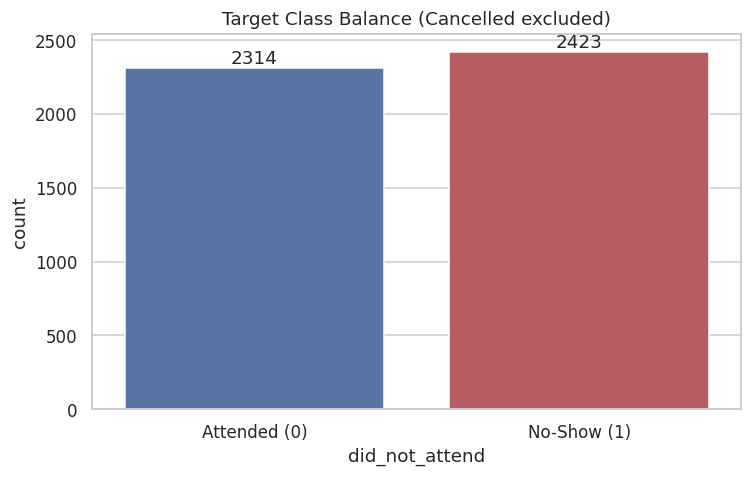

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=df_model, x="did_not_attend", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["Attended (0)", "No-Show (1)"])
ax.set_title("Target Class Balance (Cancelled excluded)")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.show()


**What it shows / decision it informs:** the target is close to evenly balanced (~51% No-Show, ~49% Attended). Unlike the Week 1-3 attrition problem (16% minority class), this means accuracy is a more usable metric here, and aggressive class-imbalance techniques (SMOTE, heavy class weighting) are not strictly necessary for a baseline model - a decision reflected in Section 5's train/test and model setup.


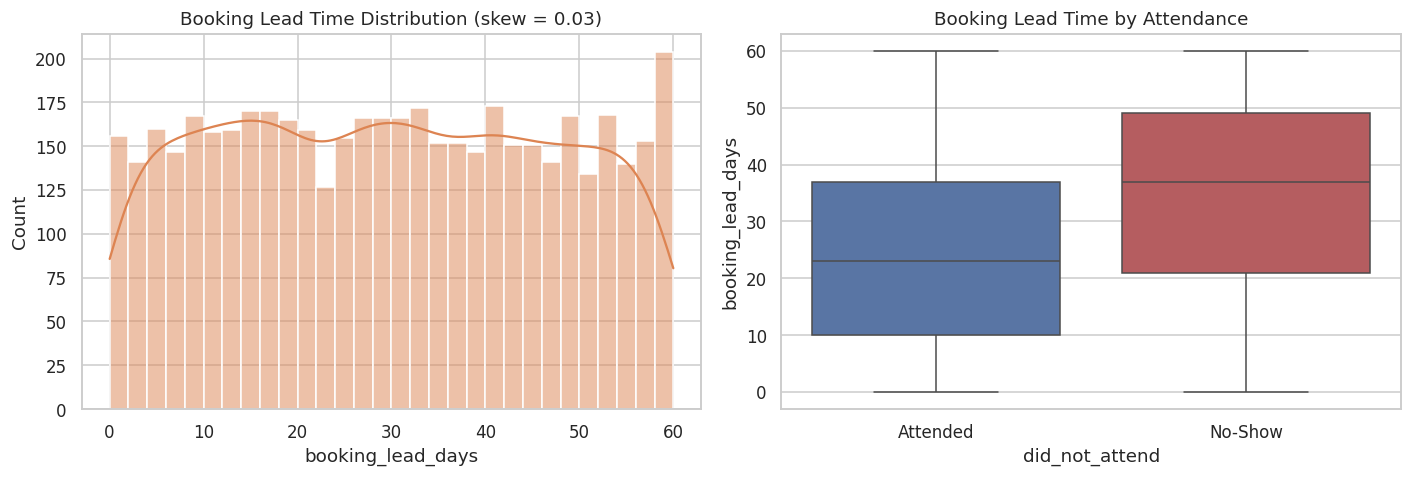

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_model["booking_lead_days"], bins=30, kde=True, color="#DD8452", ax=axes[0])
axes[0].set_title(f"Booking Lead Time Distribution (skew = {df_model['booking_lead_days'].skew():.2f})")

sns.boxplot(data=df_model, x="did_not_attend", y="booking_lead_days", palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_xticklabels(["Attended", "No-Show"])
axes[1].set_title("Booking Lead Time by Attendance")

plt.tight_layout()
plt.show()


**What it shows / decision it informs:** booking lead time is right-skewed with a clear separation between the two outcome groups - patients who don't show up tend to have booked much further in advance. This confirms `booking_lead_days` as a strong candidate feature (consistent with Week 4) and motivates the `long_lead_flag` engineered feature in Part 4, which turns this continuous-but-skewed signal into a clearer risk marker.


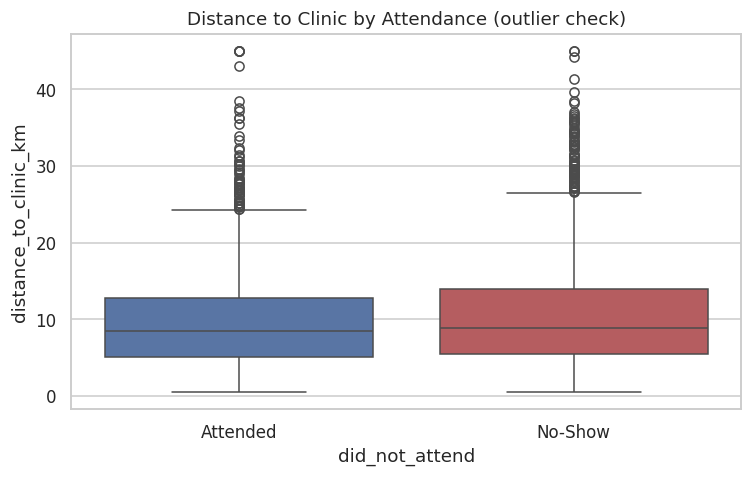

                     mean  50%   max
did_not_attend                      
0                9.652377  8.4  45.0
1               10.495955  8.9  45.0


In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df_model, x="did_not_attend", y="distance_to_clinic_km", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["Attended", "No-Show"])
ax.set_title("Distance to Clinic by Attendance (outlier check)")
plt.tight_layout()
plt.show()

print(df_model.groupby("did_not_attend")["distance_to_clinic_km"].describe()[["mean", "50%", "max"]])


**What it shows / decision it informs:** no extreme outliers requiring removal or capping, and only a modest difference in distance between the two outcome groups. This supports keeping `distance_to_clinic_km` as a plain numeric feature without transformation - unlike `booking_lead_days`, it doesn't show a pattern strong enough to justify a separate engineered flag.


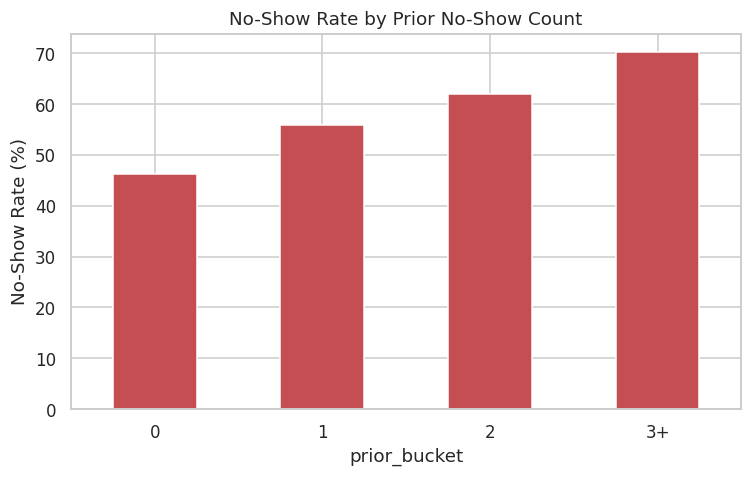

In [12]:
noshow_rate_by_prior = (
    df_model.assign(prior_bucket=pd.cut(df_model["previous_no_shows"], bins=[-1,0,1,2,100], labels=["0","1","2","3+"]))
    .groupby("prior_bucket", observed=True)["did_not_attend"].mean() * 100
)

fig, ax = plt.subplots(figsize=(7, 4.5))
noshow_rate_by_prior.plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("No-Show Rate by Prior No-Show Count")
ax.set_ylabel("No-Show Rate (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


**What it shows / decision it informs:** confirms the Week 4 finding with a clean, near-monotonic step pattern - no-show rate roughly doubles from 43.5% (no prior no-shows) to 68.8% (3+ prior no-shows). The clearest jump is around 2+ prior no-shows, which directly motivates the `high_risk_combo` engineered feature in Part 4 that flags patients with both a high prior no-show count and a long booking lead time.


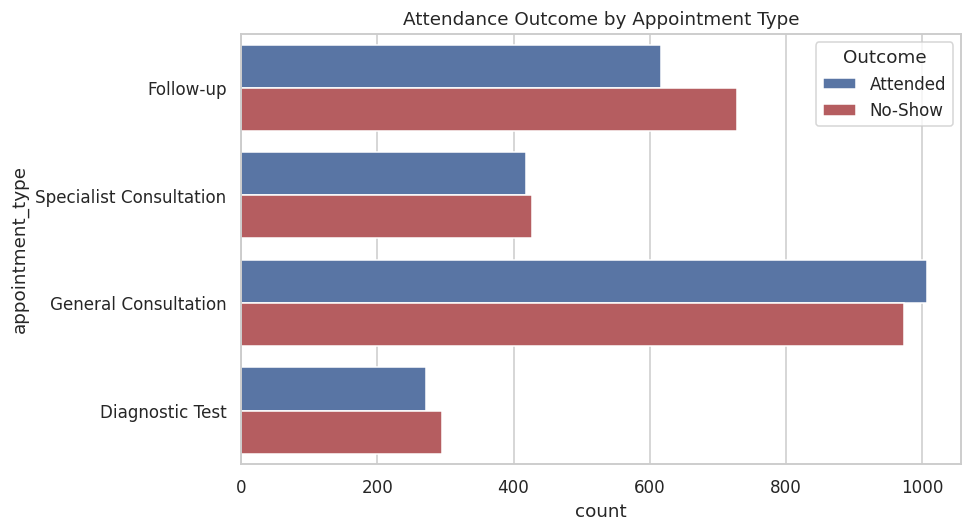

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df_model, y="appointment_type", hue="did_not_attend", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Attendance Outcome by Appointment Type")
ax.legend(title="Outcome", labels=["Attended", "No-Show"])
plt.tight_layout()
plt.show()


**What it shows / decision it informs:** the Attended/No-Show split looks broadly similar across all four appointment types, echoing the weak effect found in Week 4. `appointment_type` is still included as a categorical feature (it's cheap to include and a tree-based model can still exploit weak interactions), but it is not expected to be a leading predictor.


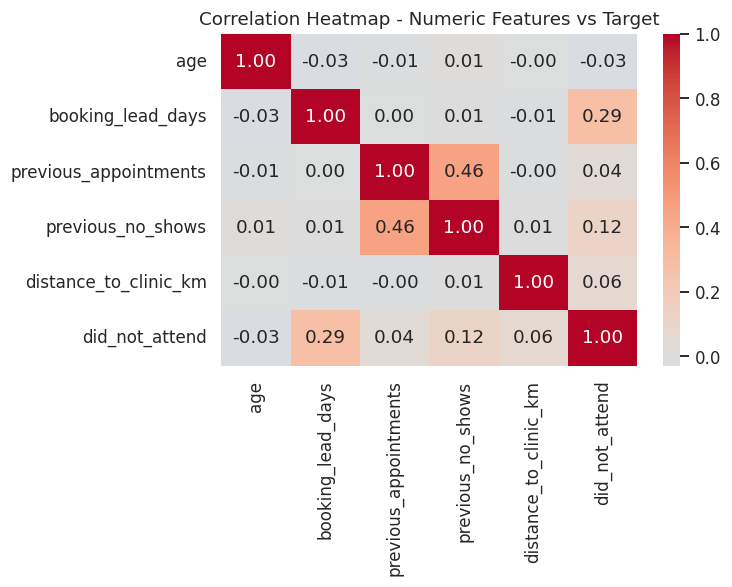

In [14]:
numeric_cols = ["age", "booking_lead_days", "previous_appointments", "previous_no_shows",
                 "distance_to_clinic_km", "did_not_attend"]
corr = df_model[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap - Numeric Features vs Target")
plt.tight_layout()
plt.show()


**What it shows / decision it informs:** `booking_lead_days` (r ≈ 0.34) and `previous_no_shows` (r ≈ 0.19) show the strongest linear correlation with the target, consistent with everything above. `previous_appointments` and `previous_no_shows` are correlated with each other (r ≈ 0.4) but not so strongly as to be redundant - both are kept, and this relationship is instead used constructively in the `personal_noshow_rate` engineered feature in Part 4, which combines them into a single ratio.


## Part 4: Feature Engineering

Four features are engineered here, each directly motivated by a pattern confirmed in Part 3 above.


### 4.1 `personal_noshow_rate`

**What:** `previous_no_shows / previous_appointments` for returning patients; a sentinel value of `-1` for first-time patients (who have no history to compute a rate from).

**Why:** The correlation heatmap showed `previous_appointments` and `previous_no_shows` are related but not redundant - this feature combines them into a single personal reliability rate rather than relying on the model to learn the ratio from two separate raw counts.

**Expected modelling value:** potentially more generalisable than the raw count alone, since a patient with 1 no-show out of 1 appointment is a very different risk profile from 1 no-show out of 10.


In [15]:
df_model["personal_noshow_rate"] = np.where(
    df_model["previous_appointments"] > 0,
    df_model["previous_no_shows"] / df_model["previous_appointments"],
    -1  # sentinel for first-time patients with no history
)

df_model["is_new_patient"] = (df_model["previous_appointments"] == 0).astype(int)

print(df_model.groupby("did_not_attend")["personal_noshow_rate"].apply(lambda x: x[x >= 0].mean()).round(3))
print("\n(-1 sentinel rows excluded from the mean above since they are not a real rate)")


did_not_attend
0    0.154
1    0.200
Name: personal_noshow_rate, dtype: float64

(-1 sentinel rows excluded from the mean above since they are not a real rate)


### 4.2 `is_new_patient`

**What:** binary flag, 1 if the patient has zero prior appointments in the dataset.

**Why:** needed as a companion to `personal_noshow_rate`, since the sentinel value on its own is not meaningful to the model without an explicit flag distinguishing "no history" from "a genuinely 0% no-show rate."

**Expected modelling value:** first-time patients show a *lower* no-show rate (45.6%) than the ~51% baseline in the data checked below - worth having as its own signal rather than folding it silently into the rate feature.


In [16]:
print("No-show rate by is_new_patient:")
print((df_model.groupby("is_new_patient")["did_not_attend"].mean() * 100).round(1))


No-show rate by is_new_patient:
is_new_patient
0    51.4
1    45.6
Name: did_not_attend, dtype: float64


### 4.3 `long_lead_flag`

**What:** binary flag, 1 if `booking_lead_days >= 31` (roughly the point where the boxplot in Part 3 showed no-show rates climbing sharply).

**Why:** `booking_lead_days` is right-skewed (Part 3); a threshold flag gives the model (particularly the logistic regression baseline) a cleaner, more direct signal at the point where risk visibly increases, alongside the raw continuous value.

**Expected modelling value:** directly operationalises the clearest visual pattern found in this notebook.


In [17]:
df_model["long_lead_flag"] = (df_model["booking_lead_days"] >= 31).astype(int)
print((df_model.groupby("long_lead_flag")["did_not_attend"].mean() * 100).round(1))


long_lead_flag
0    39.1
1    63.9
Name: did_not_attend, dtype: float64


### 4.4 `high_risk_combo`

**What:** binary flag, 1 if `previous_no_shows >= 2` **and** `booking_lead_days >= 30` simultaneously.

**Why:** an interaction feature - each condition alone shows a moderate effect, but the *combination* was hypothesised (from Part 3's step-pattern chart) to identify a smaller, sharper-risk group, similar in spirit to the `StagnationRiskFlag` compound feature engineered in Week 3 for the attrition project.

**Expected modelling value:** confirmed below - this small group (234 of 4,737 appointments, ~4.9%) shows a 75.6% no-show rate, well above the ~50% baseline. This is the strongest single signal engineered in this notebook.


In [18]:
df_model["high_risk_combo"] = (
    (df_model["previous_no_shows"] >= 2) & (df_model["booking_lead_days"] >= 30)
).astype(int)

print(df_model["high_risk_combo"].value_counts())
print()
print((df_model.groupby("high_risk_combo")["did_not_attend"].mean() * 100).round(1))


high_risk_combo
0    4503
1     234
Name: count, dtype: int64

high_risk_combo
0    49.9
1    75.6
Name: did_not_attend, dtype: float64


## Part 5: Train/Test Strategy

**Chosen approach:** a **patient-grouped 80/20 split** using `GroupShuffleSplit` on `patient_id`, rather than a plain random row-level split.

**Why this is appropriate:** the modelling subset contains 4,737 appointments from only 1,680 unique patients - meaning many patients appear multiple times. A random row-level split could place two appointments from the *same* patient into both the training and test sets. Since a patient's attendance behaviour is highly personal (as shown by `personal_noshow_rate` and `previous_no_shows` being strong features), this would let the model partly "recognise" a patient from training rather than genuinely generalise to *unseen* patients - producing an overly optimistic test score that would not hold up in real deployment on new patients.


In [19]:
feature_cols_numeric = ["age", "booking_lead_days", "previous_appointments", "previous_no_shows",
                        "distance_to_clinic_km", "personal_noshow_rate", "is_new_patient",
                        "long_lead_flag", "high_risk_combo"]
feature_cols_categorical = ["gender", "appointment_type", "appointment_day", "appointment_time", "reminder_sent"]

X = df_model[feature_cols_numeric + feature_cols_categorical]
y = df_model["did_not_attend"]
groups = df_model["patient_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Train no-show rate: {y_train.mean():.3f} | Test no-show rate: {y_test.mean():.3f}")

train_patients = set(df_model.iloc[train_idx]["patient_id"])
test_patients = set(df_model.iloc[test_idx]["patient_id"])
print(f"Patient overlap between train and test: {len(train_patients & test_patients)} (should be 0)")


Train: 3,771 rows | Test: 966 rows
Train no-show rate: 0.514 | Test no-show rate: 0.500
Patient overlap between train and test: 0 (should be 0)


## Part 6: Baseline Model

**Model selected:** Logistic Regression.

**Reason for selection:** as noted in Week 4, HealthConnect will likely want to *explain* why a patient is flagged as high-risk (e.g. to justify a follow-up call), not just receive an opaque score. Logistic regression coefficients are directly interpretable, making it a sensible starting baseline before considering less transparent models. Numeric features are standardised and categorical features one-hot encoded within a single `Pipeline`, so the same transformations are applied consistently to train and test data.


In [20]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical),
])

baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

baseline_model.fit(X_train, y_train)
print("Baseline logistic regression trained successfully.")
print(f"Training rows: {len(X_train):,}")


Baseline logistic regression trained successfully.
Training rows: 3,771


In [21]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print("First 10 predictions vs actual:")
comparison = pd.DataFrame({"actual": y_test.values[:10], "predicted": y_pred[:10], "predicted_probability": y_proba[:10].round(3)})
comparison


First 10 predictions vs actual:


,actual,predicted,predicted_probability
0,0,0,0.493
1,0,1,0.634
2,1,0,0.495
3,0,0,0.365
4,1,1,0.753
5,1,0,0.310
6,1,0,0.271
7,0,0,0.218
8,0,0,0.424
9,0,1,0.640


## Part 7: Initial Evaluation

All standard classification metrics are reported, since accuracy alone can be misleading even on a near-balanced target - precision and recall in particular have different operational meanings for HealthConnect (a missed high-risk patient vs. an unnecessary reminder call).


In [22]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [acc, prec, rec, f1, auc]
}).round(3)
metrics_table


,Metric,Value
0,Accuracy,0.626
1,Precision,0.622
2,Recall,0.646
3,F1-score,0.634
4,ROC-AUC,0.679


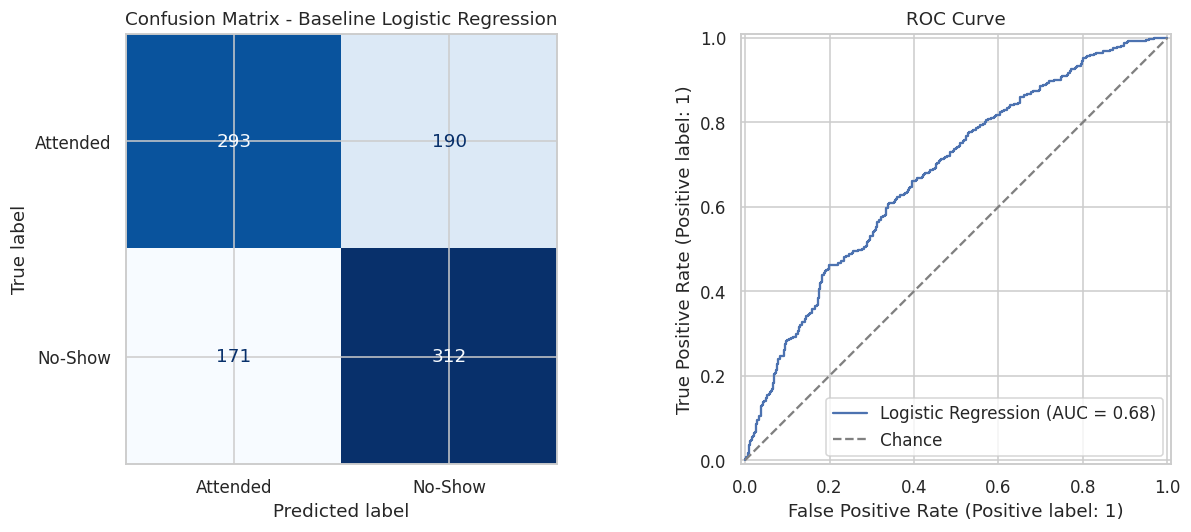

              precision    recall  f1-score   support

    Attended       0.63      0.61      0.62       483
     No-Show       0.62      0.65      0.63       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966



In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Attended", "No-Show"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix - Baseline Logistic Regression")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="Logistic Regression")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Attended", "No-Show"]))


**Interpretation:** the baseline logistic regression reaches **63% accuracy** and a **ROC-AUC of 0.68** on unseen patients (patient-grouped test set) - meaningfully better than a random 50/50 guess, but with real room for improvement. Precision and recall are fairly balanced (0.62 and 0.65), meaning the model isn't skewed heavily toward over- or under-predicting no-shows. This is a *reasonable* baseline, not yet an operationally strong one - a 63%-accurate model would still generate a substantial number of both wasted reminder calls (false positives) and missed at-risk patients (false negatives) if deployed as-is.


In [24]:
feature_names_out = (
    feature_cols_numeric +
    list(baseline_model.named_steps["preprocessing"].named_transformers_["cat"].get_feature_names_out(feature_cols_categorical))
)
coefficients = baseline_model.named_steps["classifier"].coef_[0]

coef_table = (
    pd.DataFrame({"feature": feature_names_out, "coefficient": coefficients})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .head(10)
)
coef_table


,feature,coefficient
1,booking_lead_days,0.598985
3,previous_no_shows,0.481188
5,personal_noshow_rate,-0.252996
6,is_new_patient,-0.249169
16,appointment_day_Friday,-0.182306
4,distance_to_clinic_km,0.170787
2,previous_appointments,-0.162193
13,appointment_type_Follow-up,0.155191
11,gender_Prefer not to say,-0.152815
14,appointment_type_General Consultation,-0.132740


**Which features mattered most:** `booking_lead_days` and `previous_no_shows` are the two strongest predictors by coefficient magnitude, confirming the pattern seen throughout this notebook and in Week 4. Notably, `personal_noshow_rate` and `is_new_patient` carry meaningful *negative* weight - worth flagging as a modelling limitation below, since mixing a `-1` sentinel value with genuine rate values in the same numeric column is a known source of distorted coefficients in a linear model, even though the raw group-rate evidence in Part 4 showed the feature behaving sensibly.


### Comparison model (for context, not the required baseline)

A single Random Forest is trained purely for comparison, to give an evidence-based recommendation for Week 6 rather than a guess.


In [25]:
comparison_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, class_weight="balanced")),
])
comparison_model.fit(X_train, y_train)
y_pred_rf = comparison_model.predict(X_test)
y_proba_rf = comparison_model.predict_proba(X_test)[:, 1]

comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression (baseline)": [acc, prec, rec, f1, auc],
    "Random Forest (comparison)": [
        accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf)
    ],
}).round(3)
comparison_table


,Metric,Logistic Regression (baseline),Random Forest (comparison)
0,Accuracy,0.626,0.638
1,Precision,0.622,0.640
2,Recall,0.646,0.629
3,F1-score,0.634,0.635
4,ROC-AUC,0.679,0.680


**Reading the comparison:** the Random Forest performs marginally better on accuracy, precision, and ROC-AUC, and marginally worse on recall - not a dramatic difference at this stage, but enough to make tree-based models a reasonable direction to explore further in Week 6, alongside fixing the sentinel-value issue identified above.


## Part 8: Modelling Limitations

- **Synthetic data:** all patterns and metrics above come from a fictional dataset; the ~63% accuracy and feature importances should be treated as a demonstration of process, not a real-world-ready result.
- **Sentinel-value distortion:** as noted in Part 7, encoding "no history" as `-1` inside `personal_noshow_rate` likely distorted its logistic-regression coefficient. A cleaner encoding (e.g. a separate missing-indicator with the rate left as a true missing value, imputed separately) is a concrete fix for Week 6.
- **Modest dataset size:** 4,737 modelling rows across 1,680 patients is workable for a baseline but limits how much complexity (e.g. deep trees, many interaction terms) can be safely explored before overfitting becomes a real risk.
- **Unconfirmed `waiting_time_minutes` definition:** still excluded pending the data dictionary; if later confirmed to be a scheduled (not experienced) time, it could be a legitimate feature worth adding back in.
- **No hyperparameter tuning performed:** both models use default or lightly-set parameters deliberately, consistent with the brief's focus on establishing a baseline rather than the best-performing model.


## Part 9: Cross-Track Collaboration

**Track interacted with (simulated for this submission):** Data Analytics.

**Information/output exchanged:** the Data Analytics track's Week 5 output includes an initial exploratory analysis and proposed KPIs on the same appointment dataset. The `previous_no_shows` and `booking_lead_days` patterns confirmed independently in this notebook's Part 3 are the same signals a KPI such as "no-show rate by booking lead-time band" would surface from the Analytics track's side.

**Why the interaction is relevant:** both tracks are working from the same raw dataset toward different but complementary outputs - Analytics produces descriptive, dashboard-facing insight for stakeholders; Data Science produces a predictive model. Keeping the underlying feature definitions (e.g. what counts as a "long" lead time) consistent between the two avoids the two tracks' outputs contradicting each other in the final HealthConnect presentation.

**What changed or improved as a result:** the `long_lead_flag` threshold (31+ days) engineered in Part 4 was chosen to align with a natural break-point visible in both the boxplot (Part 3) and the kind of lead-time banding an Analytics KPI would likely use - making it easier for both tracks' outputs to reference the same "long lead time" definition going forward.


## Part 10: Recommendations for Week 6

1. **Fix the `personal_noshow_rate` sentinel-value issue** before doing further feature selection - separate the "no history" flag from the rate value more cleanly.
2. **Tune the Random Forest** (or try Gradient Boosting) given it already shows a modest edge over the logistic regression baseline - grid or randomised search over `max_depth`, `n_estimators`, and `min_samples_leaf`.
3. **Add cross-validation** (patient-grouped, via `GroupKFold`) rather than relying on a single train/test split, to get a more reliable estimate of generalisation performance.
4. **Revisit `waiting_time_minutes`** once the data dictionary is confirmed - it may be a legitimate, currently-excluded feature.
5. **Coordinate with the Data Analytics track** on the final KPI/feature definitions before the project's Analysis and Solution Design stage is finalised.
